In [2]:
# Load libraries and set up environment
import os 
import sys
import importlib
import datetime
import numpy as np
import pandas as pd
import anndata as ad    
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import gffutils
import anndata as ad
import scanpy as sc 

# Ensure CUDA is available and if not use CPU
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device found")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device.type == "cuda":
    torch.set_default_tensor_type(torch.cuda.FloatTensor)

# Set seed for reproducibility
torch.manual_seed(0)

# Configure plotting styles
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import visualization.IsovizPy as ja

# Anndata file input file path 
ATSE_anndata_file="/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/BRAIN_ONLY/02112025/TMS_Anndata_ATSE_counts_with_waypoints_20250211_171237.h5ad"
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/ATSEfiles/TMS_atse_file_unanno_also_2025-01-30_19-24-18.txt.gz"

db = gffutils.FeatureDB("/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/gencodeVM19", keep_order=True)

# Load splicing anndata file along with the ATSE annotation file (both obtained using upstream processing within LeafletFA framework)
#adata = ad.read_h5ad(ATSE_anndata_file)
atses = pd.read_csv(ATSE_file, sep="\t")


Torch version: 2.4.1.post300
CUDA available: True
CUDA device count: 3
CUDA device name: NVIDIA L40S
Using device: cuda


### Summarize ATSEs

In [9]:
atses.head()

,event_id,gene_id,gene_name,num_junctions,event_type,annotation_status,junction_id,chrom,start,end,strand,cells,total_score,splice_motif,donor_seq,acceptor_seq,label_5_prime,label_3_prime,position_off_5_prime,position_off_3_prime
0,ATSE_0,ENSMUSG00000033845.13,Mrpl15,4,complex,three_prime,chr1_4774516_4776409_-,chr1,4774516,4776409,-,375,5554,GT-AG,GT,AG,annotated on 5',annotated on 3',-32.0,0.0
1,ATSE_0,ENSMUSG00000033845.13,Mrpl15,4,complex,both,chr1_4776801_4777524_-,chr1,4776801,4777524,-,21515,1230743,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0
2,ATSE_0,ENSMUSG00000033845.13,Mrpl15,4,complex,three_prime,chr1_4774516_4776405_-,chr1,4774516,4776405,-,32,251,GT-AG,GT,AG,annotated on 5',annotated on 3',-28.0,0.0
3,ATSE_0,ENSMUSG00000033845.13,Mrpl15,4,complex,both,chr1_4774516_4777524_-,chr1,4774516,4777524,-,6612,197883,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0
4,ATSE_1,ENSMUSG00000033845.13,Mrpl15,14,complex,both,chr1_4782301_4782567_-,chr1,4782301,4782567,-,893,33145,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0


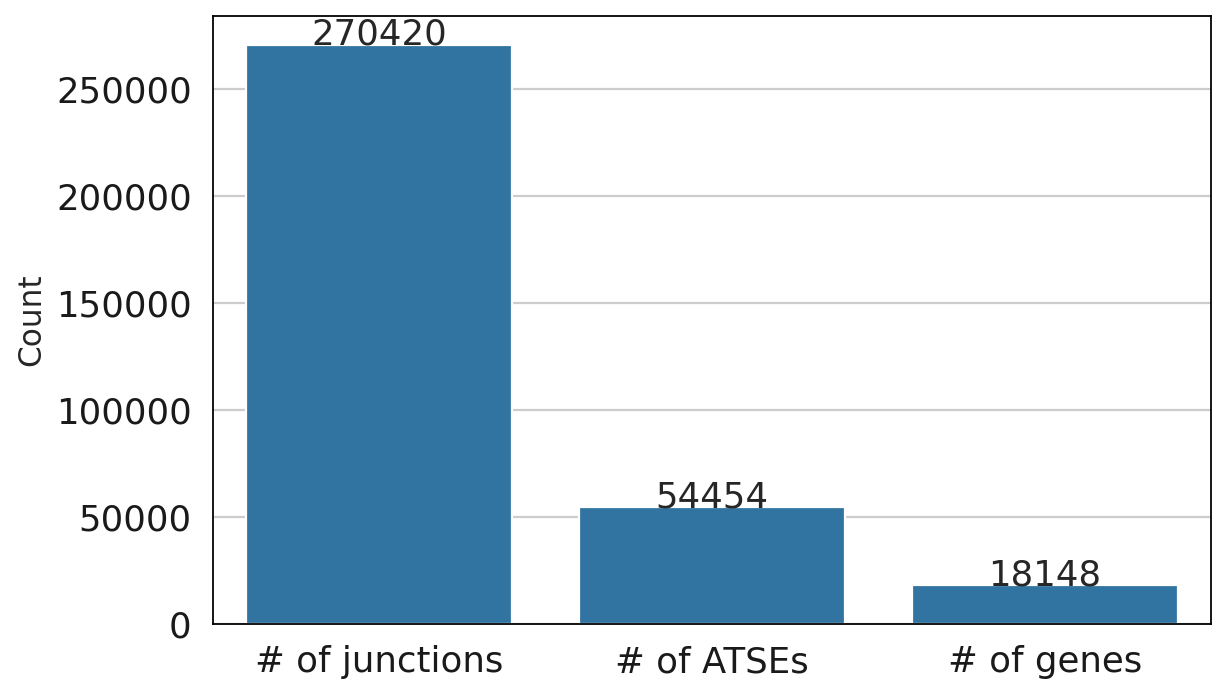

In [16]:
# 1. Number of unique junctions, event_ids and gene_ids 
# 2. annotation status freqeuency 

# summarize 
num_juncs = atses["junction_id"].nunique()
num_event_ids = atses["event_id"].nunique()
num_gene_ids = atses["gene_id"].nunique()

# make a barplot of the stats above 
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.barplot(x=["# of junctions", "# of ATSEs", "# of genes"], y=[num_juncs, num_event_ids, num_gene_ids], ax=ax)
ax.set_ylabel("Count")

# make all font sizes of all ticks and everything bigger
plt.setp(ax.get_xticklabels(), fontsize=16)
plt.setp(ax.get_yticklabels(), fontsize=16)
# print numbers on top of the bars
for i, v in enumerate([num_juncs, num_event_ids, num_gene_ids]):
    ax.text(i, v + 10, str(v), ha="center", fontsize=16)


/scratch/ipykernel_3554380/4114393429.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Junction_Annotation", y="proportion", data=annotation_status_freq, ax=ax, palette="Set2")


Text(0, 0.5, 'Proportion')

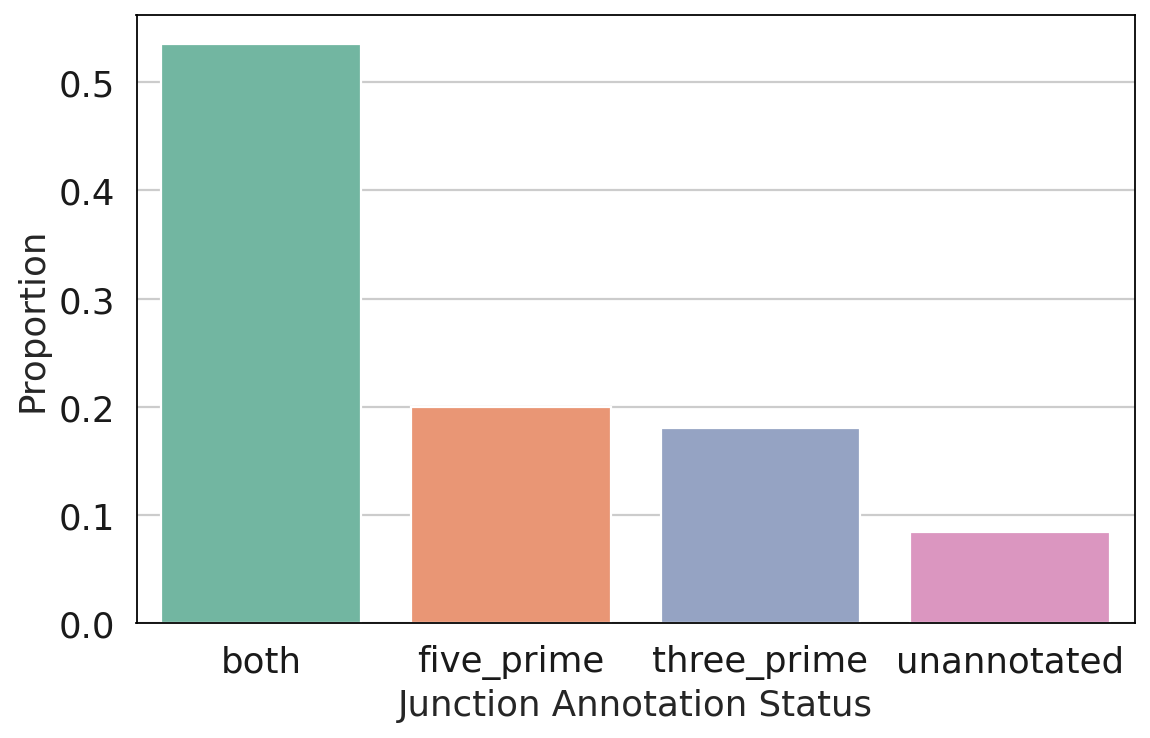

In [24]:
# Make dataframe of the annotation status frequency and plot barplot
annotation_status_freq = atses["annotation_status"].value_counts()
annotation_status_freq = annotation_status_freq / annotation_status_freq.sum()
annotation_status_freq = annotation_status_freq.reset_index()
annotation_status_freq.columns = ["Junction_Annotation", "proportion"]

# make a barplot of the stats above
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.barplot(x="Junction_Annotation", y="proportion", data=annotation_status_freq, ax=ax, palette="Set2")

# increase font size of everything all labels and all ticks
plt.setp(ax.get_xticklabels(), fontsize=16)
plt.setp(ax.get_yticklabels(), fontsize=16)
# xlab and ylab
ax.set_xlabel("Junction Annotation Status", fontsize=16)
ax.set_ylabel("Proportion", fontsize=16)


The 90th percentile is 8161.200000000012, meaning that 90% of junctions are detected in 8161.200000000012 or fewer cells.


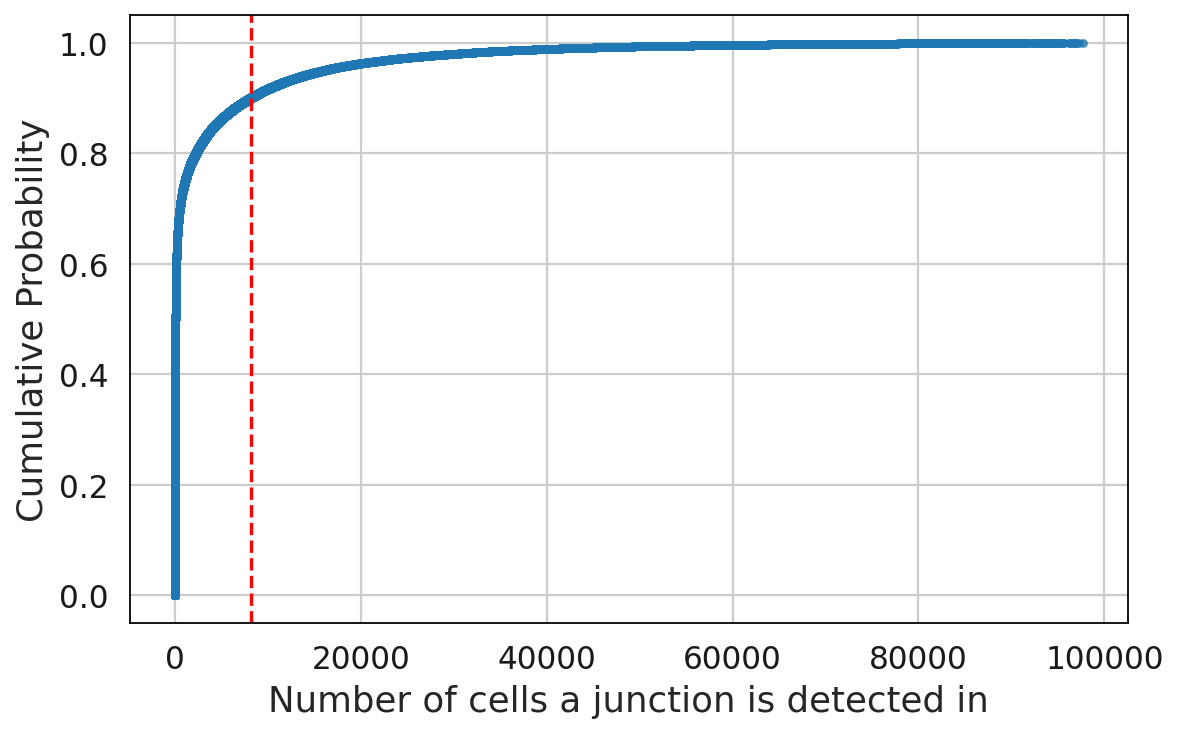

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the data
sorted_data = np.sort(atses["cells"])

# Compute the cumulative distribution
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

# Plot the CDF
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sorted_data, cdf, marker=".", linestyle="none", alpha=0.7)
ax.set_xlabel("Number of cells a junction is detected in", fontsize=16)
ax.set_ylabel("Cumulative Probability", fontsize=16)

# Draw a line at the 90th percentile
percentile_90 = np.percentile(atses["cells"], 90)
ax.axvline(percentile_90, color="red", linestyle="--", label="90th percentile")

print(f"The 90th percentile is {percentile_90}, meaning that 90% of junctions are detected in {percentile_90} or fewer cells.")

plt.show()

In [33]:
# What is the avearge number of cells a junction is detected in?
mean_cells = atses["cells"].mean()
print(f"The average number of cells a junction is detected in is {mean_cells}.")

The average number of cells a junction is detected in is 2821.408361067968.


In [72]:
atses[atses["average_number_of_reads"] > 1000].sort_values(by="total_score")

,event_id,gene_id,gene_name,num_junctions,event_type,annotation_status,junction_id,chrom,start,end,...,cells,total_score,splice_motif,donor_seq,acceptor_seq,label_5_prime,label_3_prime,position_off_5_prime,position_off_3_prime,average_number_of_reads
136868,ATSE_23375,ENSMUSG00000019772.5,Vip,2,alternative_3_prime,five_prime,chr10_5644118_5644912_+,chr10,5644118,5644912,...,13,22340,GT-AG,GT,AG,annotated on 5',annotated on 3',0.0,-2.0,1718.461538
73608,ATSE_11530,ENSMUSG00000020955.9,Ap4s1,8,complex,three_prime,chr12_51700180_51716941_+,chr12,51700180,51716941,...,13,24085,GT-AG,GT,AG,unannotated on 5',annotated on 3',NaN,1.0,1852.692308
19653,ATSE_2972,ENSMUSG00000026879.14,Gsn,291,complex,unannotated,chr2_35283943_35298810_+,chr2,35283943,35298810,...,10,34532,GC-AG,GC,AG,unannotated on 5',annotated on 3',NaN,-15.0,3453.200000
265842,ATSE_52837,ENSMUSG00000059077.6,Pth,7,complex,five_prime,chr7_113386280_113388450_-,chr7,113386280,113388450,...,25,39140,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,5.0,1565.600000
249017,ATSE_48113,ENSMUSG00000095351.2,Igkv3-2,4,alternative_5_prime,unannotated,chr6_70553570_70698766_+,chr6,70553570,70698766,...,30,42720,GT-AG,GT,AG,unannotated on 5',annotated on 3',NaN,-8.0,1424.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28113,ATSE_4217,ENSMUSG00000029580.14,Actb,88,complex,both,chr5_142904782_142905236_-,chr5,142904782,142905236,...,94693,147408885,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0,1556.703083
31737,ATSE_4755,ENSMUSG00000050708.16,Ftl1,27,complex,both,chr7_45458660_45459083_-,chr7,45458660,45459083,...,96898,163986814,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0,1692.365312
20977,ATSE_3121,ENSMUSG00000027447.6,Cst3,112,complex,both,chr2_148872043_148872816_-,chr2,148872043,148872816,...,85954,167825853,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0,1952.507772
21003,ATSE_3121,ENSMUSG00000027447.6,Cst3,112,complex,both,chr2_148872930_148875152_-,chr2,148872930,148875152,...,85959,196226344,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0,2282.789981


The 90th percentile is 58.34627530364373, meaning that 90% of junctions have an average number of reads per junction of 58.34627530364373 or fewer.


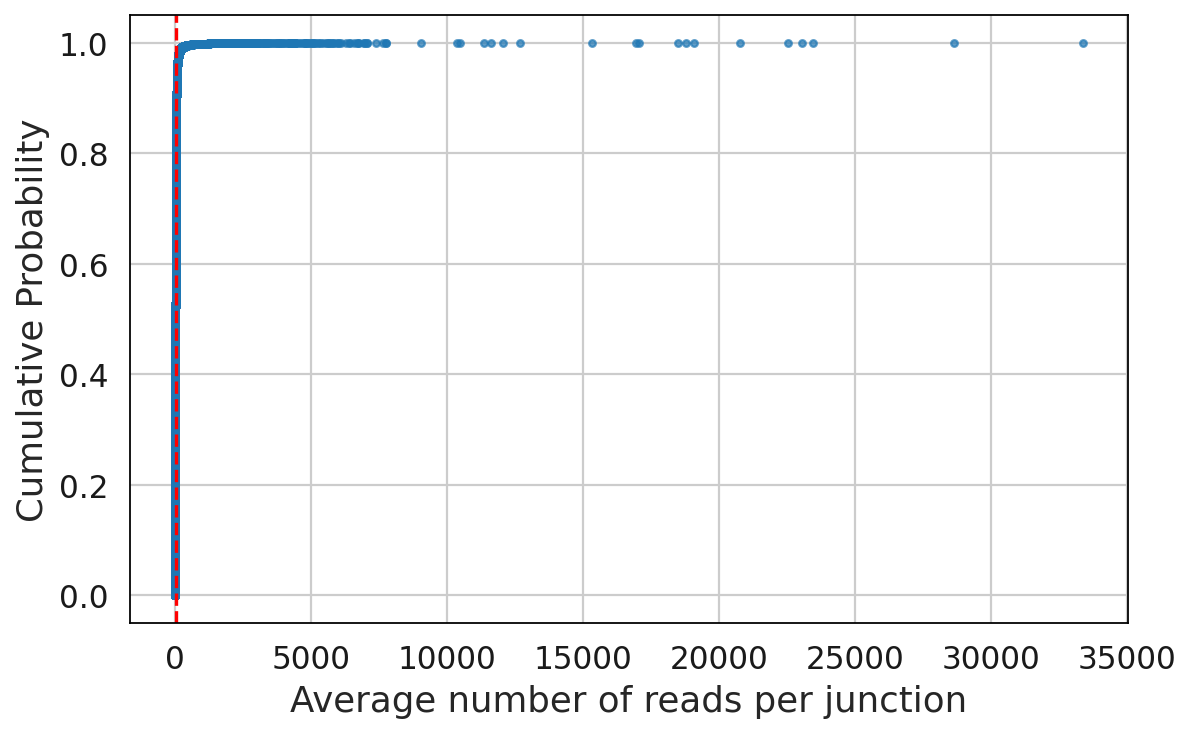

In [70]:
# Average number of reads per junction per cell 
atses["average_number_of_reads"] = atses["total_score"]/atses["cells"]

# Sort the data
sorted_data = np.sort(atses["average_number_of_reads"])

# Compute the cumulative distribution
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

# Plot the CDF
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sorted_data, cdf, marker=".", linestyle="none", alpha=0.7)
ax.set_xlabel("Average number of reads per junction", fontsize=16)
ax.set_ylabel("Cumulative Probability", fontsize=16)

# Draw a line at the 90th percentile
percentile_90 = np.percentile(atses["average_number_of_reads"], 90)
ax.axvline(percentile_90, color="red", linestyle="--", label="90th percentile")
print(f"The 90th percentile is {percentile_90}, meaning that 90% of junctions have an average number of reads per junction of {percentile_90} or fewer.")

plt.show()

In [53]:
atses.annotation_status.unique()

array(['three_prime', 'both', 'five_prime', 'unannotated'], dtype=object)

In [73]:
atse_event = "ATSE_5752"

juncs = atses[atses["event_id"]==atse_event]
juncs["usage_ratio"] = juncs["annotation_status"]
# convert cateogies to number (0: unannotated, 1: five_prime. 2: three_prime, 4: both)
juncs["usage_ratio"] = juncs["usage_ratio"].replace({"unannotated": 1, "five_prime": 2, "three_prime": 3, "both": 4})
juncs["usage_ratio"] = juncs["cells"]

juncs["Cluster"] = juncs["event_id"]
splice_junctions = ja.convert_junction_ids(juncs)

# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})


/scratch/ipykernel_3554380/3178732043.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  juncs["usage_ratio"] = juncs["annotation_status"]
/scratch/ipykernel_3554380/3178732043.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  juncs["usage_ratio"] = juncs["usage_ratio"].replace({"unannotated": 1, "five_prime": 2, "three_prime": 3, "both": 4})
/scratch/ipykernel_3554380/3178732043.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

Plot saved to Tmsb4x_usage_no_lines_20250220.pdf!


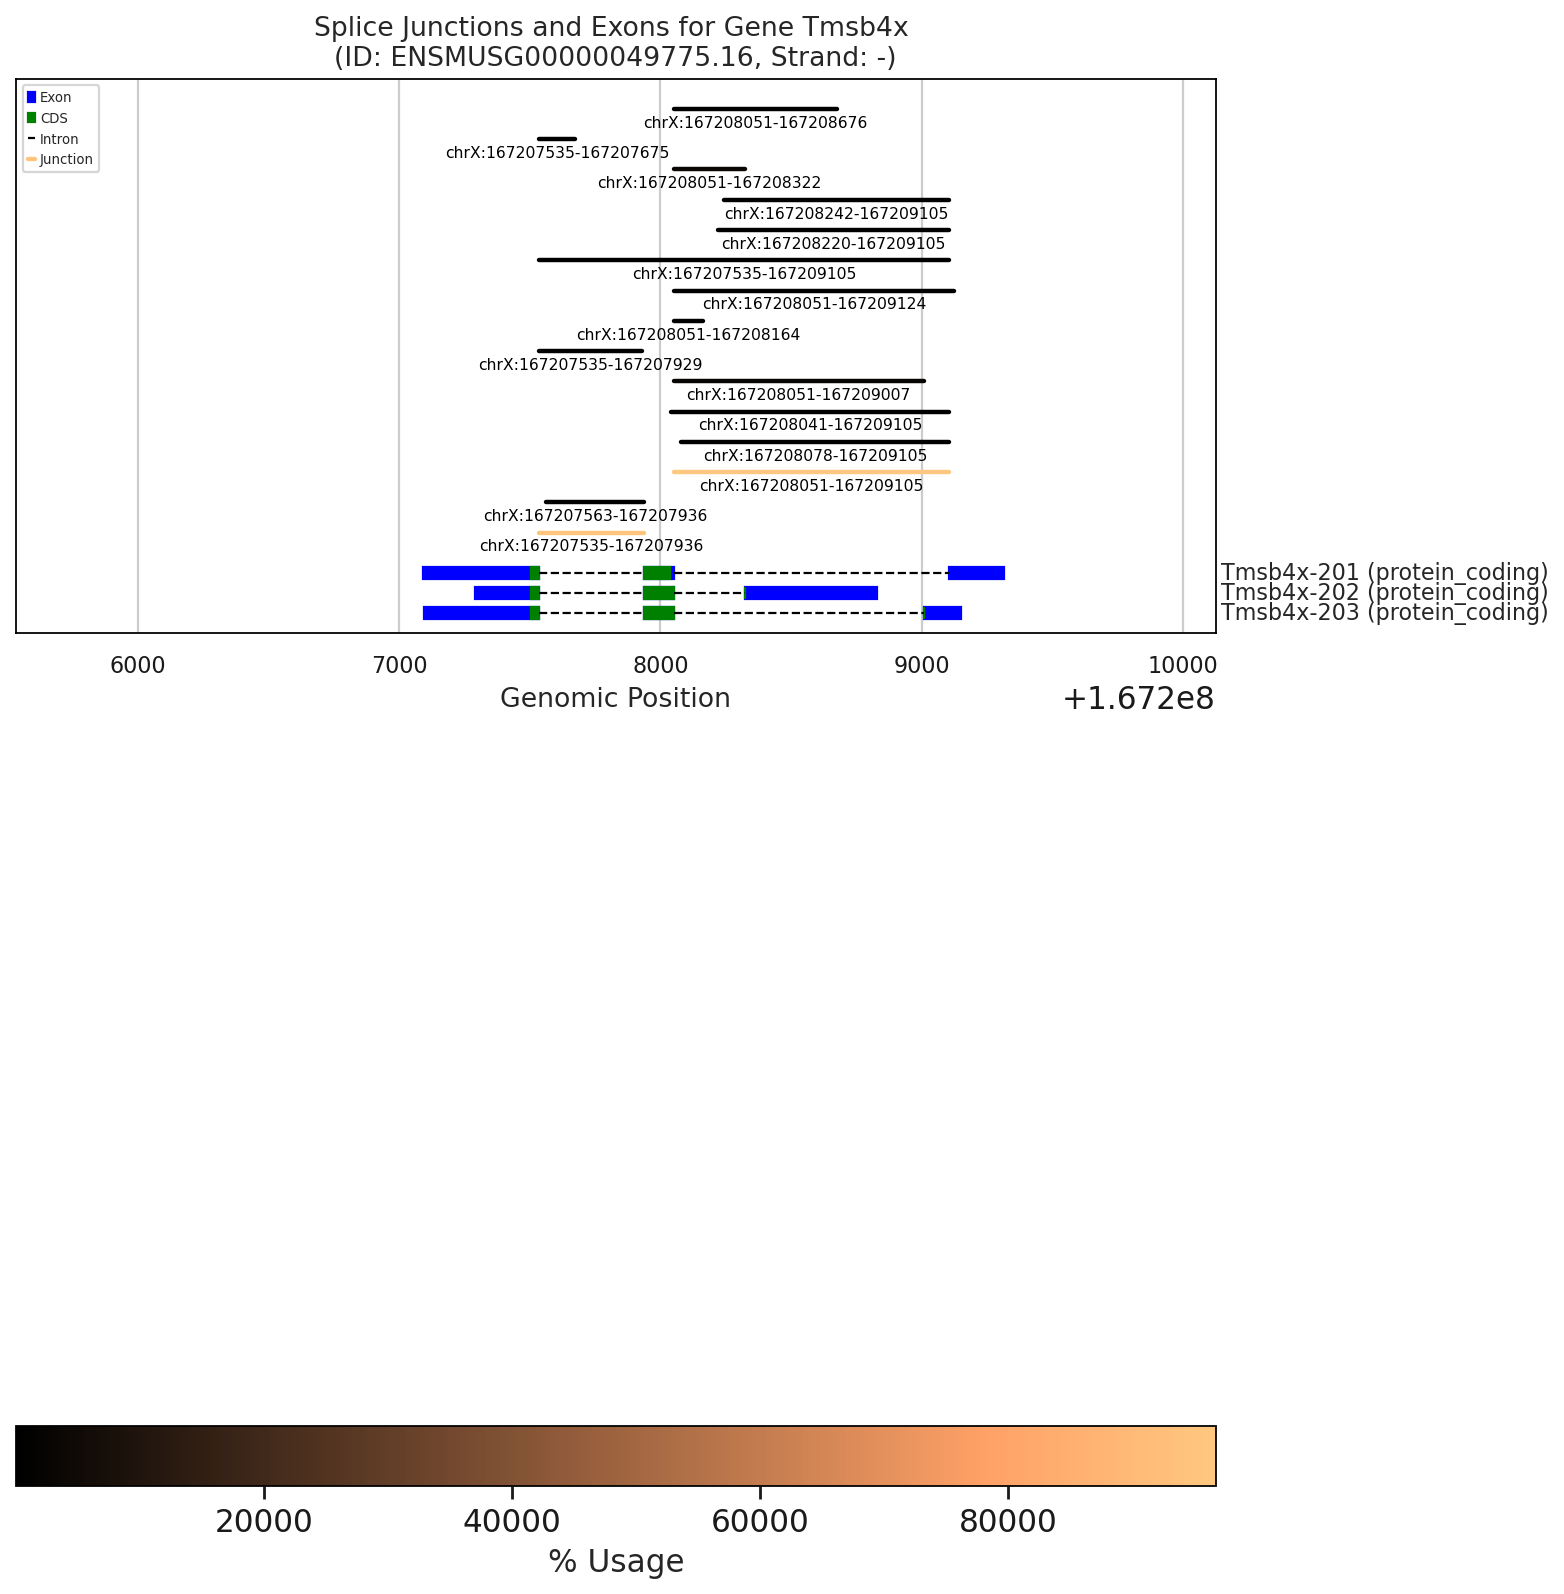

In [74]:
# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start-1000, region_end, base_width=10, trans_height=3, show_usage=True, show_junc_lines=False)
